In [171]:
import pandas as pd
import numpy as np

bars_df = pd.read_parquet("../data/bars_seen_train.parquet")
unseen_bars_df = pd.read_parquet("../data/bars_unseen_train.parquet")
sentiment_df = pd.read_csv("../sentiment_overview.csv")
headlines_df_seen = pd.read_parquet("../data/headlines_seen_train.parquet")
headlines_df_unseen = pd.read_parquet("../data/headlines_unseen_train.parquet")

# headlines_df_public = pd.read_parquet("../data/headlines_seen_public_test.parquet")
# headlines_df_private = pd.read_parquet("../data/headlines_seen_private_test.parquet")

In [177]:
import re
session_of_interest = -1
# company = "Brevon Microchips"
keyword = ""

keywords = [
    "completes planned facility upgrade",
    "warns of supply chain disruptions affecting",
    "wins industry award",
    "announces significant capital expenditure plan for",
    "withdraws from",
    "recalls products in",
    "reports rising costs pressuring margins",
    "completes strategic acquisition",
    "increase in customer acquisition",
    "loses key contract",
    "reports record quarterly",
    "names new",
    "decline in operating income",
    "secures",
    "expands operations into",
    "launches next-generation",
    "begins scheduled maintenance",
    "margin improvement",
    "drop in new customer orders this quarter",
    "reports strong demand in",
    "files routine",
    "files for regulatory",
    "explores strategic alternatives",
    "confirms participation",
    "delays product launch",
    "opens new office",
    "enters joint venture",
    "faces class action",
    "sees mixed results in",
    "board meeting",
    "misses quarterly revenue estimates",
    "faces regulatory review",
    "to host investor day focused on",
    "announces breakthrough in",
    "revises long-term strategy with focus on",
    "share buyback program",
    "signs multi-year partnership with a",
    "to present at",
    "announces restructuring plan",
    "reports unexpected decline in",
    "announces major organizational restructuring",
    "publishes annual sustainability report",
    "lowers full-year guidance amid softening demand",
    "addresses investor concerns in open letter",
    "steps down unexpectedly",
    "raises full-year guidance citing robust demand",
    "in talks for potential merger, details undisclosed",
    "achieves key regulatory milestone ahead of schedule",
    "beats analyst expectations with strong earnings growth",
    "schedules annual shareholder meeting for next month"
]
all_day_company_session_keywords = []

for session_of_interest in range(1000):
    headlines_seen = headlines_df_seen[headlines_df_seen["session"] == session_of_interest]
    headlines_seen = headlines_seen[headlines_seen["headline"].str.contains("secures", na=False)]
    headlines_unseen = headlines_df_unseen[headlines_df_unseen["session"] == session_of_interest]
    headlines_unseen = headlines_unseen[headlines_unseen["headline"].str.contains("secures", na=False)]
    df = pd.concat([headlines_seen, headlines_unseen])
    if df.empty:
        continue
    for idx, row in df.iterrows():
        print(row.headline)


Orevex Renewables secures $500M contract with a global retailer
Calvis Sciences secures $650M contract with a leading cloud platform
Yorvov Pharmaceuticals secures $180M contract with a national infrastructure agency
Relvos Biosciences secures $320M contract with a leading cloud platform
Orevex Renewables secures $650M contract with a major logistics provider
Yorvov Pharmaceuticals secures $120M contract with a multinational manufacturer
Relvos Biosciences secures $800M contract with a national infrastructure agency
Orevex Renewables secures $120M contract with an international consortium
Jorvis Fuels secures $400M contract with an international consortium
Jorvis Fuels secures $75M contract with a multinational manufacturer
Strynal Industries secures $320M contract with a leading cloud platform
Kelvik Power secures $800M contract with a leading cloud platform
Kelvik Power secures $800M contract with a national infrastructure agency
Prynis Systems secures $320M contract with a top-tier 

In [173]:
import pandas as pd

# 1. Combine both DataFrames once upfront
headlines_df = pd.concat([headlines_df_seen, headlines_df_unseen], ignore_index=True)

# 2. Build one big boolean mask for ALL keywords at once
pattern = "|".join(map(re.escape, keywords))
keyword_mask = headlines_df["headline"].str.contains(pattern, na=False, regex=True)
filtered_df = headlines_df[keyword_mask].copy()

# 3. Tag each row with which keyword(s) it matched — vectorized
def find_keyword(headline):
    for kw in keywords:
        if kw in headline:
            return kw
    return None

filtered_df["matched_keyword"] = filtered_df["headline"].apply(find_keyword)
filtered_df["first_two_words"] = filtered_df["headline"].str.split().str[:2].str.join(" ")

# 4. Build result with no Python loops
all_day_company_session_keywords = list(
    zip(
        filtered_df["bar_ix"],
        filtered_df["first_two_words"],
        filtered_df["session"],
        filtered_df["matched_keyword"],
    )
)

print(list(filter(lambda x: x[2] == 0 and x[1] == "Relvos Biosciences", all_day_company_session_keywords)))

[(6, 'Relvos Biosciences', 0, 'opens new office'), (14, 'Relvos Biosciences', 0, 'names new'), (26, 'Relvos Biosciences', 0, 'decline in operating income'), (26, 'Relvos Biosciences', 0, 'secures'), (55, 'Relvos Biosciences', 0, 'secures'), (68, 'Relvos Biosciences', 0, 'to present at')]


In [174]:
pharma_cluster = [
"Calvis Sciences",
"Calvos Genomics",
"Frelis Genomics",
"Grevel Diagnostics",
"Grevon Biotech",
"Jorvix Diagnostics",
"Krevum Pharmaceuticals",
"Myrnon Therapeutics",
"Nerval Biopharma",
"Relvos Biosciences",
"Wyrnik Sciences",
"Xelvol Biotech",
"Yorvov Pharmaceuticals",
"Zelvix Therapeutics",
"Zelvon Biosciences",
"Zrovum Biopharma"]

energy_cluster = [
"Jorvis Fuels",
"Kelvik Power",
"Kelvos Resources",
"Nerven Grid",
"Nolvol Resources",
"Orevex Renewables",
"Orevov Solutions",
"Plevep Power",
"Plevik Energy",
"Relvon Fuels",
"Strynal Industries",
"Ulvon Renewables",
"Urvel Grid",
"Wyrnor Solutions",
"Zelval Energy",
"Zrovex Industries"]

commerce_cluster = [
"Arnik Commerce",
"Arnos Marketplace",
"Crevol Retail",
"Frelex Outlets",
"Halvav Brands",
"Holtar Stores",
"Ixenis Outlets",
"Jorval Trading",
"Joval Brands",
"Nolvav Commerce",
"Orevar Marketplace",
"Pleven Trading",
"Talvyn Goods",
"Varvov Retail",
"Xovep Stores",
"Xovol Goods"]

money_cluster = [
"Creven Securities",
"Ervan Capital",
"Halven Investments",
"Halvix Holdings",
"Holtum Asset",
"Ilval Financial",
"Jorvyl Securities",
"Jovik Asset",
"Krevan Investments",
"Plevum Partners",
"Plevyl Advisors",
"Talvix Holdings",
"Wrelal Financial",
"Yorval Partners",
"Zelvel Capital",
"Zrovov Advisors"]

hardware_cluster = [
"Brevep Systems",
"Brevon Microchips",
"Crevex Labs",
"Dralol Computing",
"Frelol Software",
"Halvax Networks",
"Ixenix Technologies",
"Jovor Networks",
"Myrnep Technologies",
"Nolvis Devices",
"Prynis Systems",
"Relvan Software",
"Talvep Computing",
"Ulvyn Microchips",
"Volval Devices",
"Yorven Labs"
]

clusters = [pharma_cluster, energy_cluster, commerce_cluster, money_cluster, hardware_cluster]

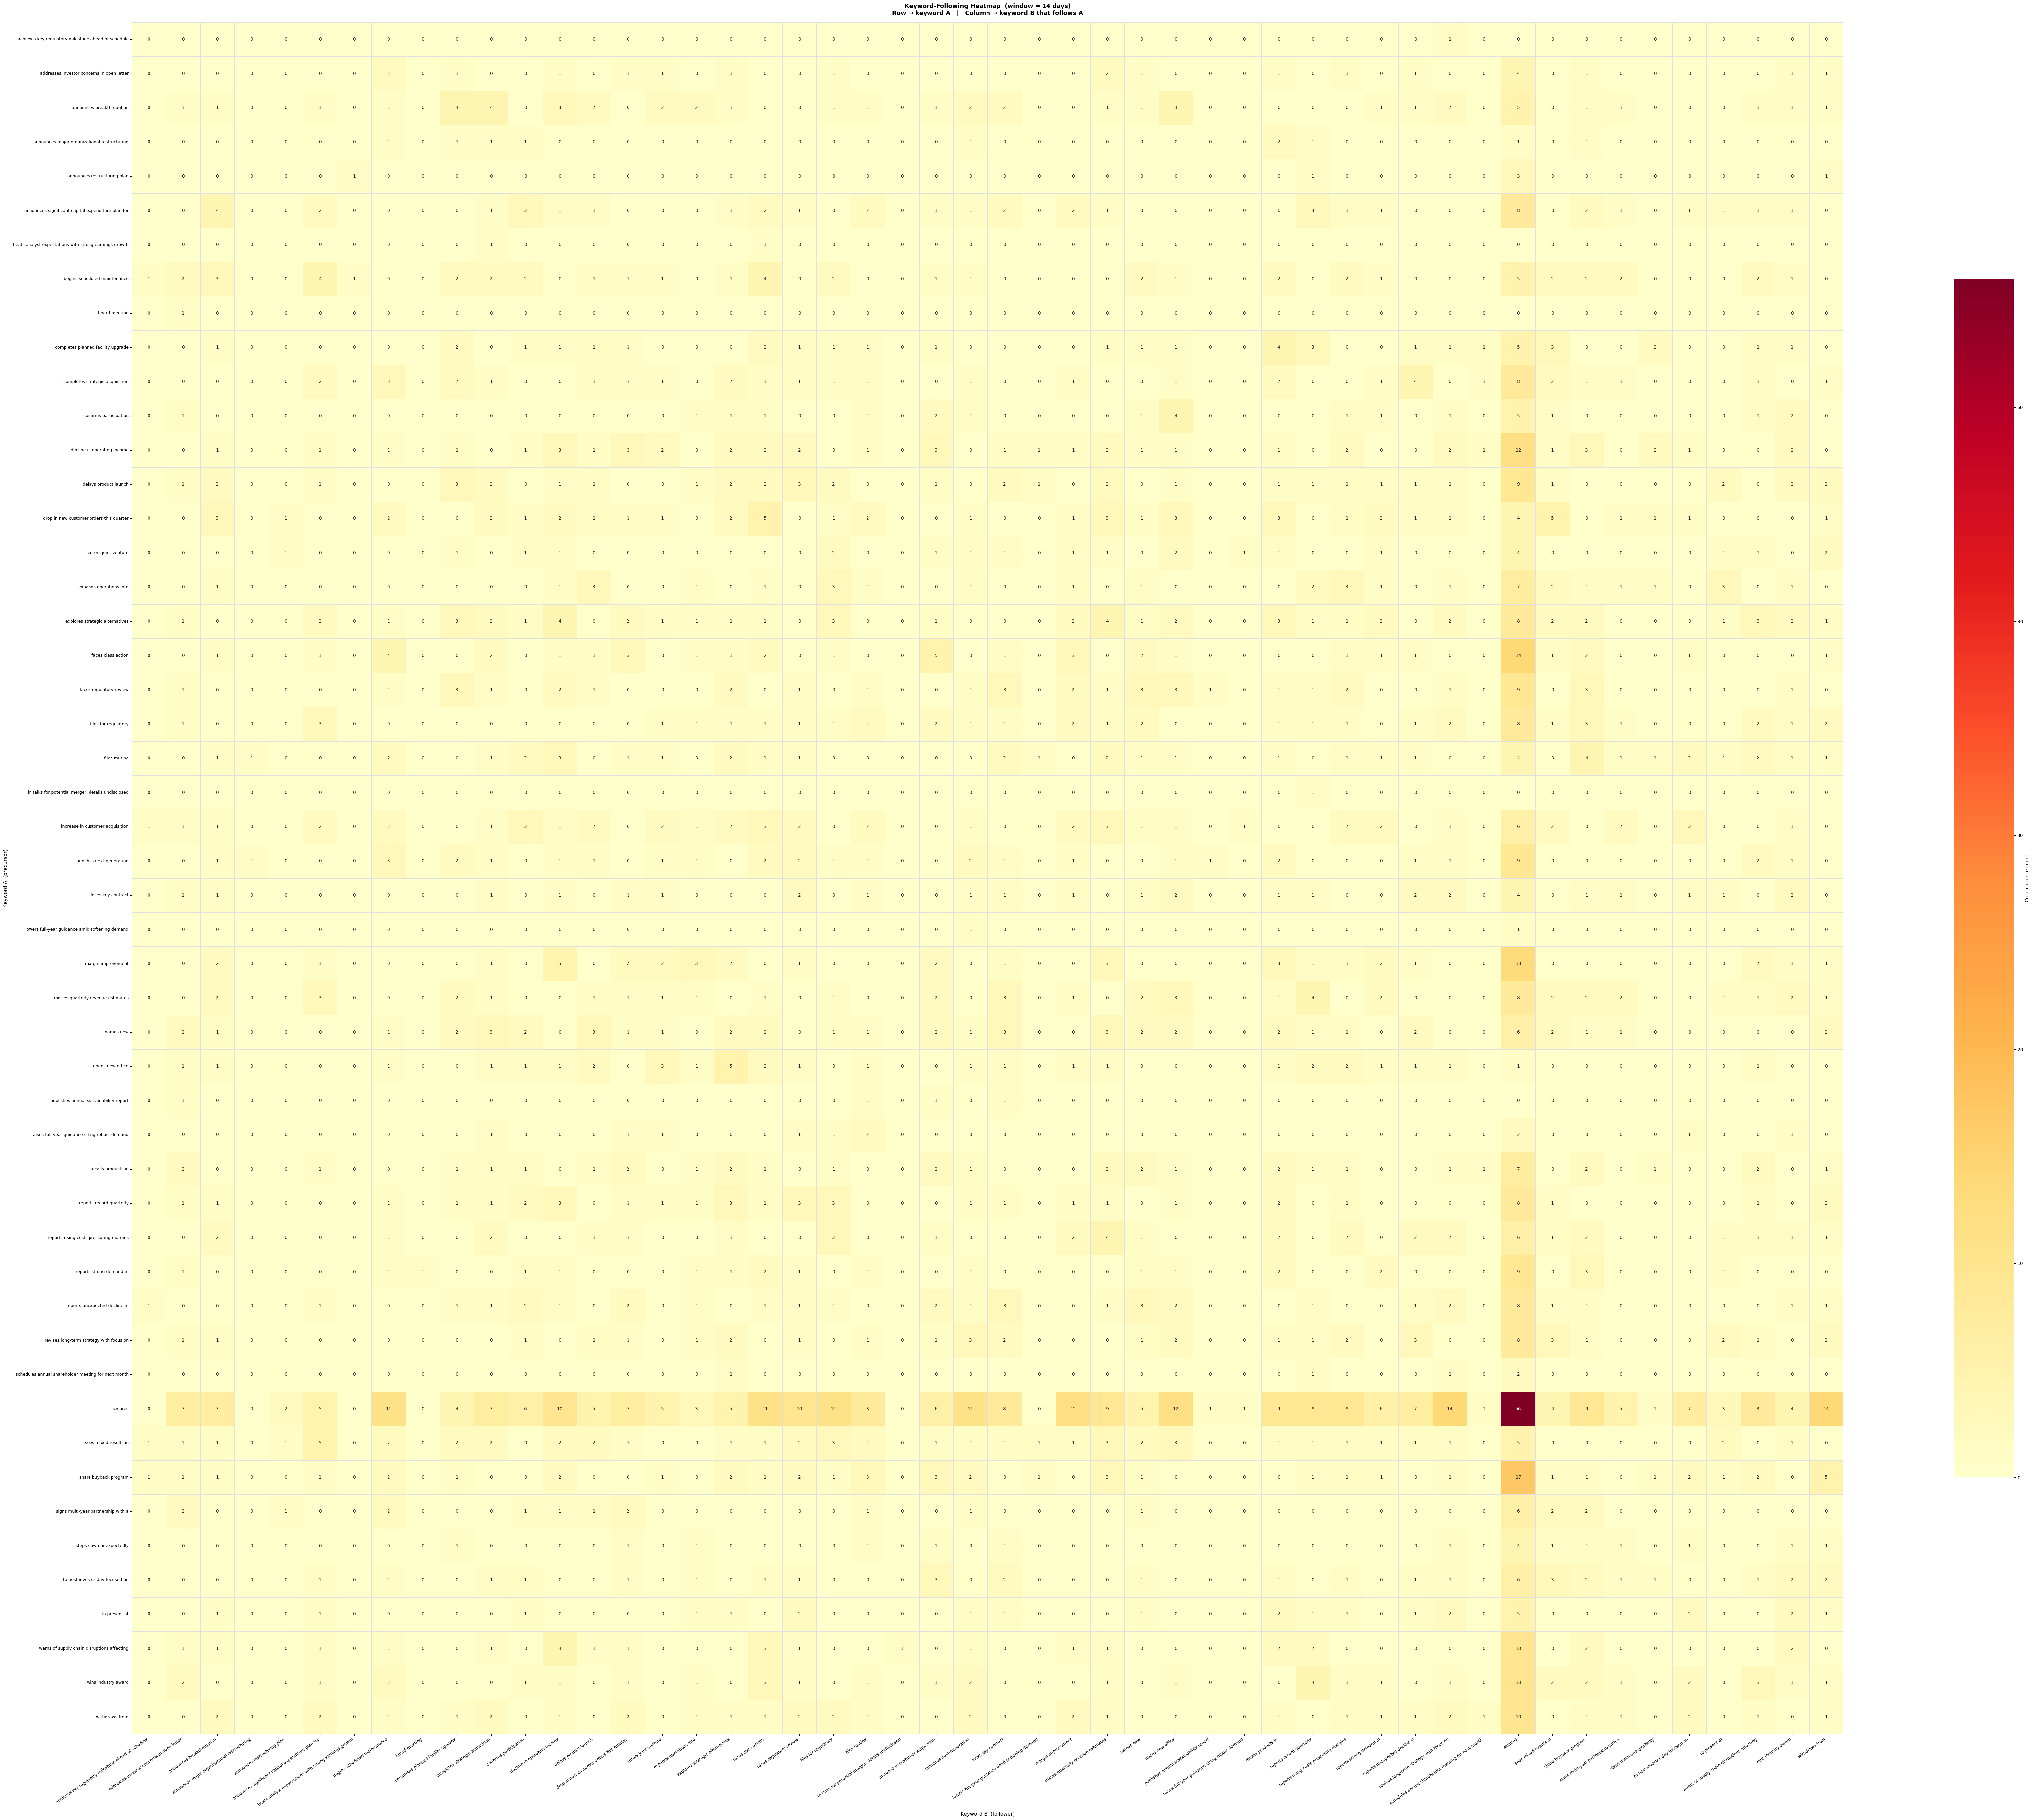

Saved → keyword_heatmap.png

Co-occurrence matrix:
                                                        achieves key regulatory milestone ahead of schedule  addresses investor concerns in open letter  announces breakthrough in  announces major organizational restructuring  announces restructuring plan  announces significant capital expenditure plan for  beats analyst expectations with strong earnings growth  begins scheduled maintenance  board meeting  completes planned facility upgrade  completes strategic acquisition  confirms participation  decline in operating income  delays product launch  drop in new customer orders this quarter  enters joint venture  expands operations into  explores strategic alternatives  faces class action  faces regulatory review  files for regulatory  files routine  in talks for potential merger, details undisclosed  increase in customer acquisition  launches next-generation  loses key contract  lowers full-year guidance amid softening demand  margin imp

In [175]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
from collections import defaultdict
from itertools import permutations

# ── Data ──────────────────────────────────────────────────────────────────────
data = all_day_company_session_keywords

# ── Parameters ────────────────────────────────────────────────────────────────
WINDOW_DAYS = 14   # <── adjust this: max days between two headlines to count as "following"

# ── Build co-occurrence matrix ────────────────────────────────────────────────
def build_cooccurrence(records, window_days):
    """
    For each (company, session_id) group, count how often keyword B follows
    keyword A within `window_days` days (A appears on day_A <= day_B).
    
    Returns a DataFrame where matrix[A][B] = count of (A → B) pairs.
    """
    df = pd.DataFrame(records, columns=['day', 'company', 'session_id', 'keyword'])
    df = df[df["company"].isin(money_cluster)]
    df = df.sort_values(['company', 'session_id', 'day']).reset_index(drop=True)

    counts = defaultdict(int)

    for (company, session), group in df.groupby(['company', 'session_id']):
        rows = group[['day', 'keyword']].values.tolist()  # [[day, kw], ...]

        for i, (day_a, kw_a) in enumerate(rows):
            for j, (day_b, kw_b) in enumerate(rows):
                if i == j:
                    continue
                # B follows A: same or later day, within the window
                if 0 <= (day_b - day_a) <= window_days:
                    counts[(kw_a, kw_b)] += 1

    # Collect all unique keywords
    all_kws = sorted(df['keyword'].unique())

    # Build square matrix
    matrix = pd.DataFrame(0, index=all_kws, columns=all_kws)
    for (kw_a, kw_b), cnt in counts.items():
        matrix.loc[kw_a, kw_b] = cnt

    return matrix

matrix = build_cooccurrence(data, WINDOW_DAYS)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(7, len(matrix) * 1.4),
                                max(5, len(matrix) * 1.1)))

sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.6,
    linecolor='#e0e0e0',
    square=True,
    cbar_kws={'label': 'Co-occurrence count', 'shrink': 0.7},
    ax=ax,
)

ax.set_title(
    f'Keyword-Following Heatmap  (window = {WINDOW_DAYS} days)\n'
    f'Row → keyword A   |   Column → keyword B that follows A',
    fontsize=13, fontweight='bold', pad=16
)
ax.set_xlabel('Keyword B  (follower)', fontsize=11, labelpad=10)
ax.set_ylabel('Keyword A  (precursor)', fontsize=11, labelpad=10)

plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(f"./keyword_heatmap_Relvos_Biosciences_{WINDOW_DAYS}days_window_money_cluster.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → keyword_heatmap.png")
print("\nCo-occurrence matrix:")
print(matrix.to_string())